<a href="https://colab.research.google.com/github/HamzaEric/gan-dcgan-art-generation/blob/main/Notebooks/DCGAN_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Purpose of This Notebook**

This notebook focuses on developing intuition for **GAN evaluation** and understanding **common failure modes**, including:
- **Mode collapse:** when the generator produces near-identical outputs.
- **Training instability:** when the adversarial balance between generator and discriminator breaks down.
- **Loss of diversity:** when the generator ignores style or color variations present in real data.

# GANs Evaluation

GANs **do not model data likelihood** directly.  
There is no single scalar metric that tells us whether the generator has truly captured the data distribution.

Mathematically, the GAN objective is:

$$
\min_G \max_D V(D, G) =
\mathbb{E}_{x \sim p_{data}} [\log D(x)] +
\mathbb{E}_{z \sim p_z} [\log (1 - D(G(z)))]
$$

This *adversarial min–max game* measures how effectively $G$ can fool $D$,  
but it **does not directly reflect visual quality** or the diversity of generated images.

**The Subjectivity of “Realism”**

What does *realistic* even mean in the context of art?

- A perfectly blended color palette?  
- A composition that mimics brush strokes of real paintings?  
- Or something that evokes human emotion or aesthetic appeal?

Unlike datasets containing faces or everyday objects, **artistic realism is subjective and multidimensional**.  
Perception of realism depends on human taste, artistic conventions, and cultural interpretation — making objective evaluation nearly impossible.


**The GAN Evaluation Triangle**

These three aspects — **realism**, **diversity**, and **stability** — often exist in **tension**.  
Improving one can sometimes degrade the others.  
For instance, pushing too hard for image sharpness might cause mode collapse, while encouraging too much diversity might reduce realism.

The trade-off can be visualized as a conceptual triangle:

```text
           +---------------------+
           |      REALISM        |
           |   (Image Quality)   |
           +---------------------+
                   /\
                  /  \
                 /    \
       DIVERSITY ------ STABILITY
   (Variety)              (Training Balance)
```

In [10]:
import torch
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
import torchvision

In [3]:
!mkdir -p ckpt_path

!mv D_dcgan_epoch_*.pth G_dcgan_epoch_*.pth ckpt_path/

 Pretrained DCGAN Generator loaded successfully on CPU with feature_g=32.


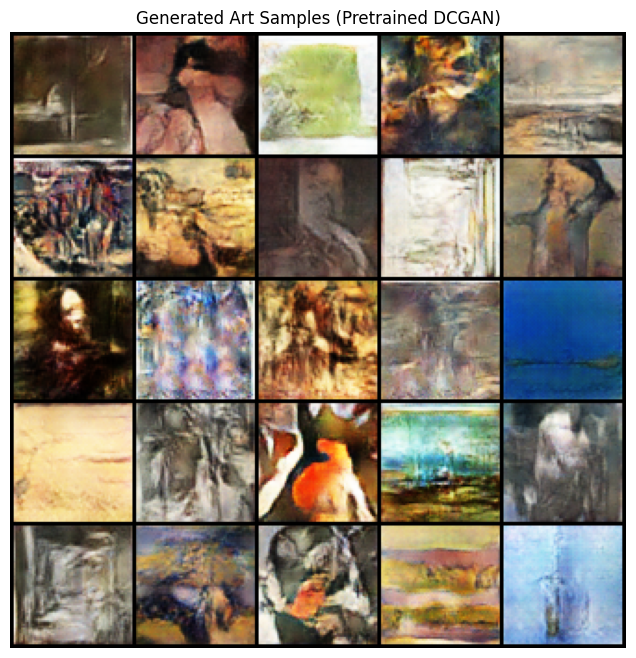

In [6]:
device = torch.device("cpu")

class GeneratorDCGAN(nn.Module):
    def __init__(self, z_dim=100, feature_g=64, channels_img=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feature_g*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g*8),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*8, feature_g*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*4, feature_g*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g*2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_g, channels_img, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


G_pretrained = GeneratorDCGAN(z_dim=100, feature_g=32, channels_img=3).to(device)
state = torch.load("/content/ckpt_path/G_dcgan_epoch_200.pth", map_location=device)
G_pretrained.load_state_dict(state, strict=True)

# 3. Strip away TPU bfloat16 precision so the CPU can process it
G_pretrained = G_pretrained.float()
G_pretrained.eval()
print(" Pretrained DCGAN Generator loaded successfully on CPU with feature_g=32.")


# --- Generate random art samples ---
# z shape (N, z_dim, 1, 1) directly matches the ConvTranspose2d expectation
z = torch.randn(25, 100, 1, 1, device=device)

with torch.no_grad():
    fake_images = G_pretrained(z).detach().cpu()

# --- Denormalize and visualize ---
grid = utils.make_grid(fake_images, nrow=5, normalize=True)
plt.figure(figsize=(8, 8))

# 4. Explicitly convert the PyTorch tensor to a Numpy array for Matplotlib
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Generated Art Samples (Pretrained DCGAN)")
plt.show()

# **Visual Comparison Across Epochs**

One of the most insightful ways to understand **how GANs learn** is to **observe their visual evolution over epochs**.  
Unlike conventional neural networks—where decreasing loss usually signals improvement—GANs often **oscillate** or **destabilize** during training.  
Hence, visual progression offers a more reliable lens into what the generator is actually learning.


We will compare outputs from three versions of the **DCGAN Generator**:

- `dcgan_epoch_50.pth` → *Early stage:* random-like blobs and color noise  
- `dcgan_epoch_100.pth` → *Mid stage:* emerging structure and texture hints  
- `dcgan_pretrained_150.pth` → *Late stage:* refined, coherent, and stylistically rich results  

By generating all images from the **same latent vectors $z$**, we can clearly see how the generator gradually learns to:
- Capture **global structure** before local detail.  
- Refine **color harmony, edges, and texture coherence**.  

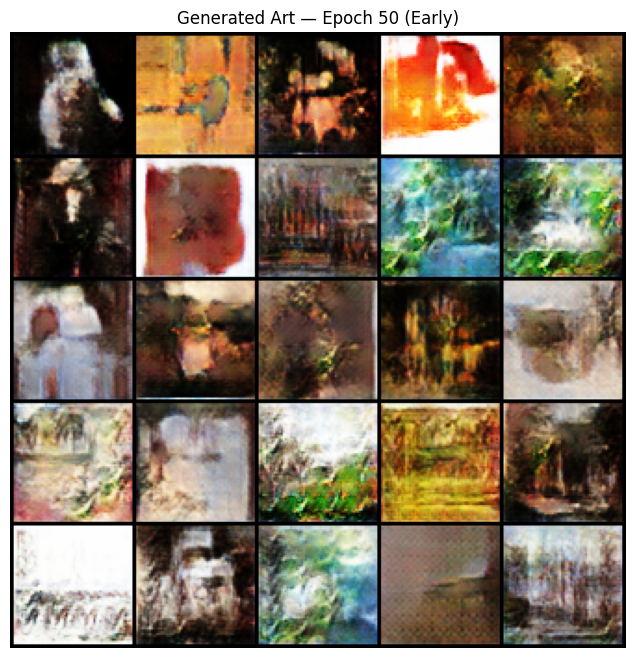

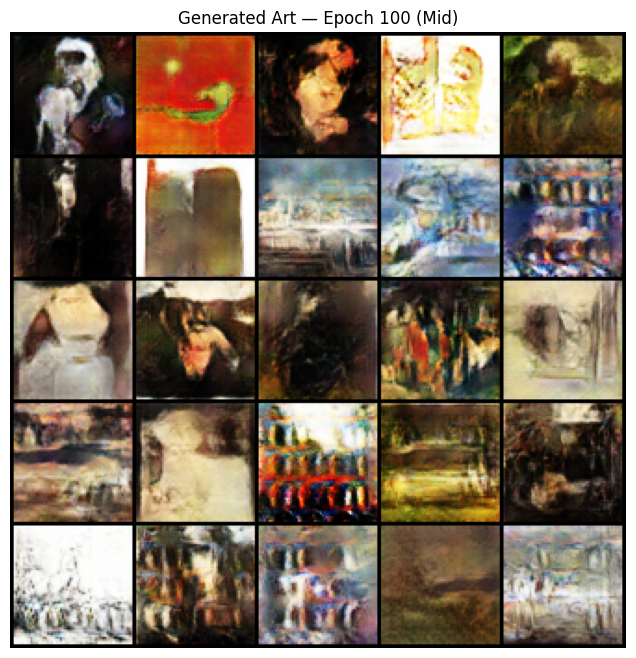

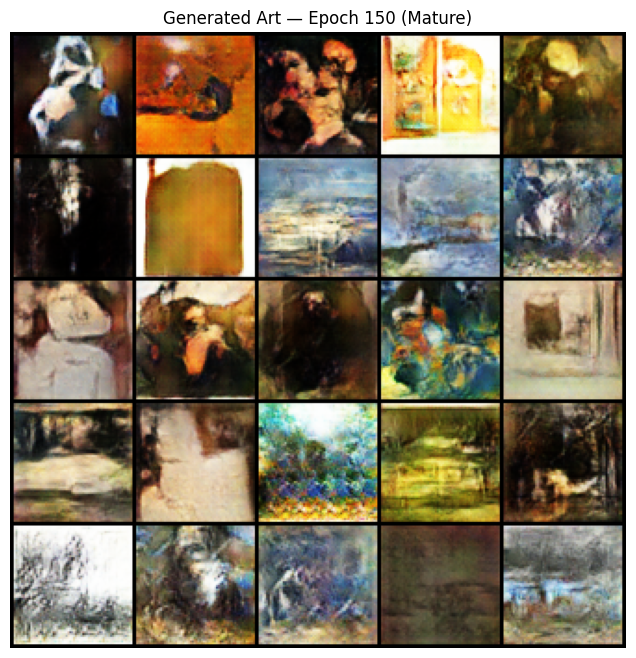

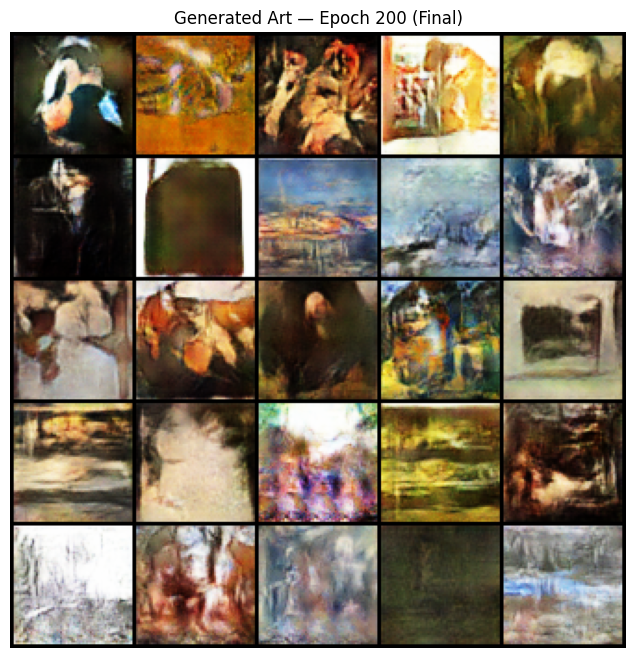

In [9]:
def show_grid(images, title, nrow=5):
    grid = utils.make_grid(images, nrow=nrow, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

fixed_z = torch.randn(25, 100, 1, 1, device=device)

# --- Function to load a checkpoint and generate images ---
def generate_from_checkpoint(ckpt_filename):
    model = GeneratorDCGAN(z_dim=100, feature_g=32).to(device)

    full_path = f"ckpt_path/{ckpt_filename}"

    model.load_state_dict(torch.load(full_path, map_location=device))

    model = model.float()
    model.eval()

    with torch.no_grad():
        imgs = model(fixed_z).detach().cpu()
    return imgs

# --- Compare across epochs ---
checkpoints = {
    "Epoch 50 (Early)": "G_dcgan_epoch_50.pth",
    "Epoch 100 (Mid)": "G_dcgan_epoch_100.pth",
    "Epoch 150 (Mature)": "G_dcgan_epoch_150.pth",
    "Epoch 200 (Final)": "G_dcgan_epoch_200.pth"
}

for stage, filename in checkpoints.items():
    imgs = generate_from_checkpoint(filename)
    show_grid(imgs, f"Generated Art — {stage}")

#### **Understanding Mode Collapse**

**What is mode collapse (and why we care)?**  
In a balanced art dataset, we expect our generator $G$ to produce **diverse** paintings: different styles, palettes, brush textures, and compositions.  
**Mode collapse** happens when $G$ maps many different latent vectors $z \sim \mathcal{N}(0, I)$ to **very similar outputs** (e.g., the same color blobs or a single recurring composition).  

**Intuition:**  
- If the Discriminator $D$ provides **strong gradients** for one particular kind of image, $G$ can learn a “shortcut”: produce only that kind of image to fool $D$.  
- This **imbalance** in the adversarial game reduces diversity: $G$ “wins” locally but **fails** to represent the full data distribution.

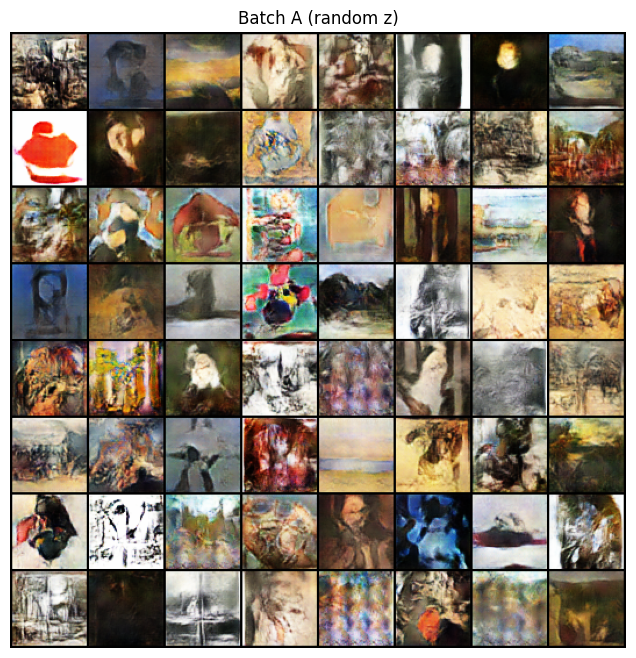

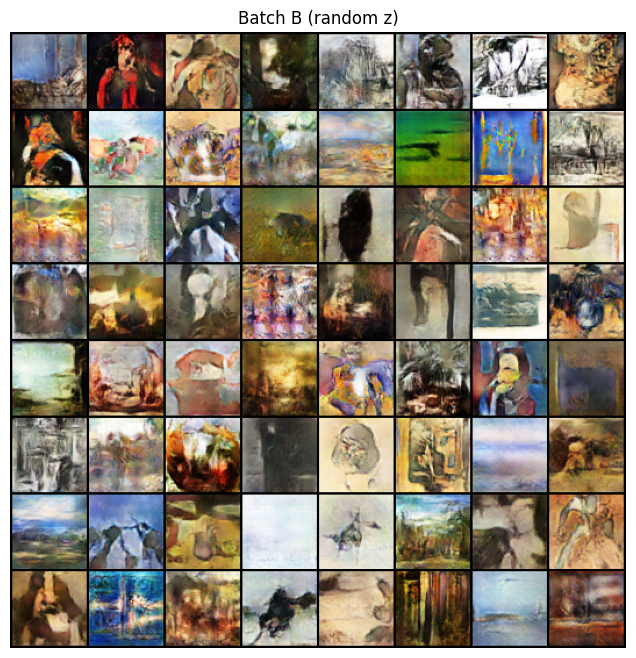

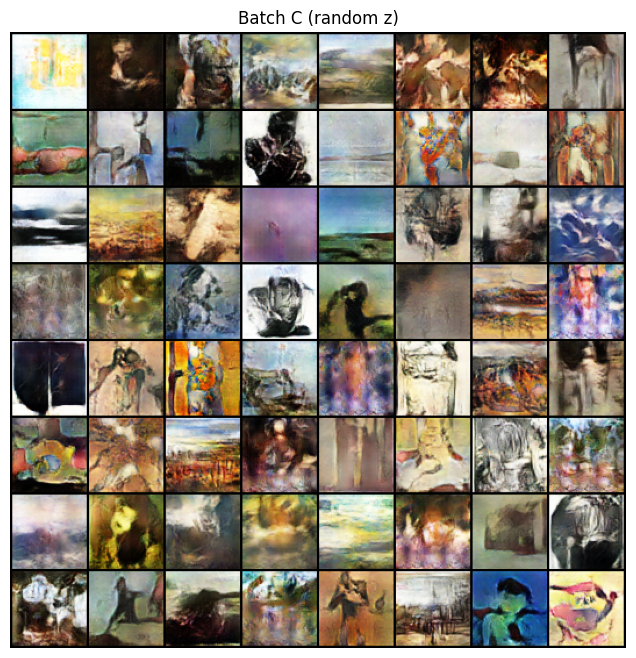

Diversity heuristics (higher std, lower cosine similarity are better):
Batch A: pixel_std=0.2665, mean_cos_sim=0.1111
Batch B: pixel_std=0.2464, mean_cos_sim=0.0985
Batch C: pixel_std=0.2511, mean_cos_sim=0.0868


In [11]:

assert 'G_pretrained' in globals() or 'G' in globals(), "Load a generator first (e.g., Section 2)."
G_eval = G_pretrained if 'G_pretrained' in globals() else G
G_eval.eval()

device = next(G_eval.parameters()).device
latent_dim = 100

# Helper: denormalize from [-1,1] to [0,1]
def denorm(x):
    return (x + 1) / 2

# 1) VISUAL CHECK — generate multiple batches of samples
def show_batch(title, imgs, nrow=8):
    grid = torchvision.utils.make_grid(denorm(imgs).cpu(), nrow=nrow, padding=2, normalize=False)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

with torch.no_grad():
    # Generate 3 different batches from different z’s
    batch_sizes = [64, 64, 64]
    z1 = torch.randn(batch_sizes[0], latent_dim, 1, 1, device=device)
    z2 = torch.randn(batch_sizes[1], latent_dim, 1, 1, device=device)
    z3 = torch.randn(batch_sizes[2], latent_dim, 1, 1, device=device)

    f1 = G_eval(z1)
    f2 = G_eval(z2)
    f3 = G_eval(z3)

show_batch("Batch A (random z)", f1, nrow=8)
show_batch("Batch B (random z)", f2, nrow=8)
show_batch("Batch C (random z)", f3, nrow=8)

# 2) SIMPLE DIVERSITY HEURISTICS (no heavy dependencies)
#    - Pixelwise std across the batch (higher is better)
#    - Mean pairwise cosine similarity between flattened images (lower is better)

def batch_diversity_scores(imgs):
    # imgs: (N, 3, 64, 64) in [-1,1]
    x = denorm(imgs).clamp(0,1)                      # (N,3,64,64) in [0,1]
    x_np = x.cpu().numpy()
    N = x_np.shape[0]

    # Pixelwise std aggregated
    std_per_pixel = x_np.std(axis=0)                 # (3,64,64)
    mean_pixel_std = std_per_pixel.mean()            # scalar

    # Mean pairwise cosine similarity on flattened vectors
    X = x.view(N, -1)                                # (N, 3*64*64)
    X = X - X.mean(dim=1, keepdim=True)              # zero-center each sample
    X = X / (X.norm(dim=1, keepdim=True) + 1e-8)     # l2-normalize
    sims = []
    for i in range(N):
        # compare with 10 random others to keep it light
        idxs = torch.randint(low=0, high=N, size=(10,))
        dot = (X[i, None, :] * X[idxs, :]).sum(dim=1)  # cosine similarity
        sims.append(dot.mean().item())
    mean_cos_sim = float(np.mean(sims))

    return mean_pixel_std, mean_cos_sim

with torch.no_grad():
    s1 = batch_diversity_scores(f1)
    s2 = batch_diversity_scores(f2)
    s3 = batch_diversity_scores(f3)

print("Diversity heuristics (higher std, lower cosine similarity are better):")
print(f"Batch A: pixel_std={s1[0]:.4f}, mean_cos_sim={s1[1]:.4f}")
print(f"Batch B: pixel_std={s2[0]:.4f}, mean_cos_sim={s2[1]:.4f}")
print(f"Batch C: pixel_std={s3[0]:.4f}, mean_cos_sim={s3[1]:.4f}")

**How to interpret the results**

- **Visual inspection:**  
  If many samples look **very similar** (same colors, same blobs, same layout) across different $z$ values, that’s a red flag for **mode collapse**.

- **Heuristics:**  
  - **Pixel std across the batch** (scalar):  
    Higher values usually indicate **greater variety** across samples.  
  - **Mean pairwise cosine similarity** (scalar):  
    Lower values usually indicate **less redundancy** (i.e., images are more distinct).

These are **lightweight checks** (not formal metrics like FID/IS), but they help us sense whether diversity is present.